In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. MATH FUNCTION: SKILLS SCORE ---
def calc_skills_math(user_skills_set, jd_keywords_set):
    """
    Formula: 40 * (Intersection / User Skills)
    """
    intersection = len(user_skills_set.intersection(jd_keywords_set))
    total_user_skills = len(user_skills_set)

    if total_user_skills == 0:
        return 0, 0, 0

    score = 40 * (intersection / total_user_skills)
    return round(score, 2), intersection, total_user_skills

# --- 2. MATH FUNCTION: EDUCATION SCORE ---
def calc_education_math(resume_edu_text, jd_text):
    """
    Formula: 20 (Degree Check) + 10 * (Cosine Similarity)
    """
    # A. Degree Indicator (Simple keyword check)
    degree_keywords = ['bachelor', 'master', 'phd', 'b.tech', 'm.tech']
    degree_present = 1 if any(kw in resume_edu_text.lower() for kw in degree_keywords) else 0
    degree_points = degree_present * 20

    # B. Cosine Similarity (TF-IDF)
    try:
        vectorizer = TfidfVectorizer()
        tfidf_matrix = vectorizer.fit_transform([resume_edu_text, jd_text])
        # Similarity is element [0,1] in the matrix
        sim_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    except:
        sim_score = 0.0 # Fallback if texts are too short/empty

    semantic_points = 10 * sim_score
    total_score = min(30, degree_points + semantic_points) # Cap at 30

    return round(total_score, 2), degree_points, round(sim_score, 4), round(semantic_points, 2)

# --- 3. MATH FUNCTION: EXPERIENCE SCORE ---
def calc_experience_math(resume_years, required_years):
    """
    Formula: 20 if (Resume >= Required) ELSE 20 * (Resume / Required)
    """
    if resume_years >= required_years:
        return 20.0, "Max Points"
    else:
        score = 20 * (resume_years / required_years)
        return round(score, 2), f"Ratio: {resume_years}/{required_years}"

# --- 4. MATH FUNCTION: SEMANTIC FIT ---
def calc_semantic_math(cosine_sim_value):
    """
    Formula: 10 * Cosine Similarity
    """
    return round(10 * cosine_sim_value, 2)

print("Mathematical Functions Loaded Successfully.")

Mathematical Functions Loaded Successfully.


In [ ]:
# --- INPUT DATA ---

# 1. Skills (Sets)
candidate_skills = {'Python', 'SQL', 'React', 'Machine Learning'}
jd_keywords = {'Python', 'Django', 'SQL', 'AWS', 'React', 'TensorFlow'}

# 2. Education (Text Strings)
resume_education = "Master of Science in Computer Science from Stanford University. Specialized in AI."
job_description_text = "We are looking for a Master's graduate with strong CS fundamentals. Experience with Python and Cloud is required."

# 3. Experience (Years)
candidate_exp_years = 4
required_exp_years = 5

# 4. Semantic Similarity (Simulated for this example)
# In a real app, this comes from the Neural Network model.
# Let's assume the model calculated a 0.85 similarity between resume and JD.
semantic_similarity_model_output = 0.85

print("Candidate Data Defined.")
print(f"Candidate Skills: {candidate_skills}")
print(f"JD Keywords: {jd_keywords}")
print(f"Candidate Exp: {candidate_exp_years} years (Required: {required_exp_years})")

Candidate Data Defined.
Candidate Skills: {'Python', 'Machine Learning', 'React', 'SQL'}
JD Keywords: {'Django', 'TensorFlow', 'Python', 'React', 'AWS', 'SQL'}
Candidate Exp: 4 years (Required: 5)


In [ ]:
print("=" * 60)
print("MATHEMATICAL CALCULATION REPORT: John Doe")
print("=" * 60)

# --- STEP 1: SKILLS SCORE ---
print("\n[1] SKILLS SCORE CALCULATION")
s_score, s_inter, s_tot = calc_skills_math(candidate_skills, jd_keywords)
print(f"   Formula: 40 x ( |User Skills ∩ JD Skills| / |User Skills| )")
print(f"   Input  : User Skills = {candidate_skills}")
print(f"           JD Keywords   = {jd_keywords}")
print(f"   Math   : Intersection Count = {s_inter}")
print(f"           Total User Skills   = {s_tot}")
print(f"   Calc   : 40 x ({s_inter} / {s_tot}) = 40 x {s_inter/s_tot:.2f}")
print(f"   Result : {s_score} / 40")

# --- STEP 2: EDUCATION SCORE ---
print("\n[2] EDUCATION SCORE CALCULATION")
e_score, e_deg_pts, e_sim, e_sem_pts = calc_education_math(resume_education, job_description_text)
print(f"   Formula: Min( 30, (Degree_Pts) + (10 x Cosine_Sim) )")
print(f"   Input  : Resume Edu = '{resume_education}'")
print(f"   A. Degree Check: Found 'Master' -> 20 pts")
print(f"   B. TF-IDF Similarity: {e_sim}")
print(f"   Math   : 20 + (10 x {e_sim}) = 20 + {e_sem_pts}")
print(f"   Result : {e_score} / 30")

# --- STEP 3: EXPERIENCE SCORE ---
print("\n[3] EXPERIENCE SCORE CALCULATION")
x_score, x_status = calc_experience_math(candidate_exp_years, required_exp_years)
print(f"   Formula: 20 x (Resume_Years / Required_Years)")
print(f"   Input  : Candidate has {candidate_exp_years} years, JD requires {required_exp_years} years.")
print(f"   Calc   : 20 x ({candidate_exp_years} / {required_exp_years})")
print(f"   Result : {x_score} / 20")

# --- STEP 4: SEMANTIC FIT SCORE ---
print("\n[4] SEMANTIC FIT CALCULATION")
m_score = calc_semantic_math(semantic_similarity_model_output)
print(f"   Formula: 10 x (Neural_Network_Similarity)")
print(f"   Input  : Model Output Similarity = {semantic_similarity_model_output}")
print(f"   Calc   : 10 x {semantic_similarity_model_output}")
print(f"   Result : {m_score} / 10")

# --- FINAL TOTAL ---
print("\n" + "=" * 60)
print("FINAL SCORE CALCULATION")
print("=" * 60)
total = s_score + e_score + x_score + m_score
print(f" Total = Skills ({s_score}) + Edu ({e_score}) + Exp ({x_score}) + Semantic ({m_score})")
print(f" TOTAL = {total} / 100")

MATHEMATICAL CALCULATION REPORT: John Doe

[1] SKILLS SCORE CALCULATION
   Formula: 40 x ( |User Skills ∩ JD Skills| / |User Skills| )
   Input  : User Skills = {'Python', 'Machine Learning', 'React', 'SQL'}
           JD Keywords   = {'Django', 'TensorFlow', 'Python', 'React', 'AWS', 'SQL'}
   Math   : Intersection Count = 3
           Total User Skills   = 4
   Calc   : 40 x (3 / 4) = 40 x 0.75
   Result : 30.0 / 40

[2] EDUCATION SCORE CALCULATION
   Formula: Min( 30, (Degree_Pts) + (10 x Cosine_Sim) )
   Input  : Resume Edu = 'Master of Science in Computer Science from Stanford University. Specialized in AI.'
   A. Degree Check: Found 'Master' -> 20 pts
   B. TF-IDF Similarity: 0.0299
   Math   : 20 + (10 x 0.0299) = 20 + 0.3
   Result : 20.3 / 30

[3] EXPERIENCE SCORE CALCULATION
   Formula: 20 x (Resume_Years / Required_Years)
   Input  : Candidate has 4 years, JD requires 5 years.
   Calc   : 20 x (4 / 5)
   Result : 16.0 / 20

[4] SEMANTIC FIT CALCULATION
   Formula: 10 x (Neur

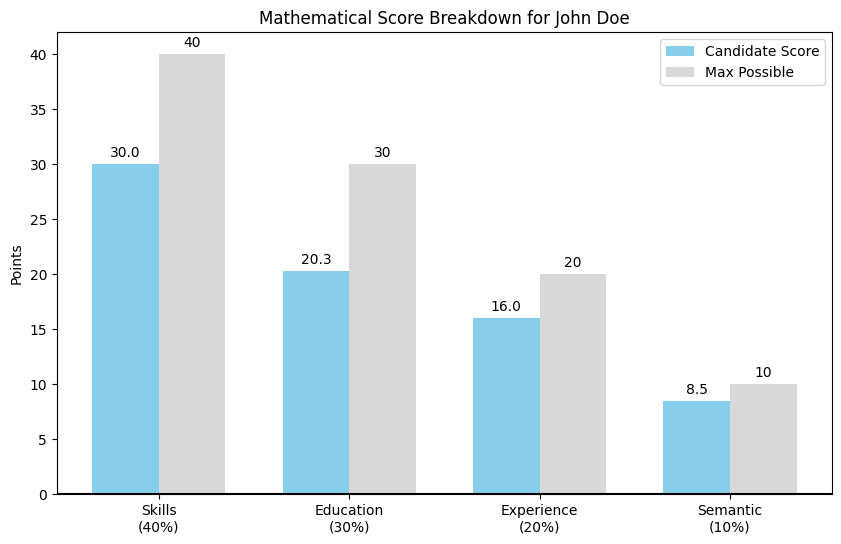

In [ ]:
# Data for plotting
categories = ['Skills\n(40%)', 'Education\n(30%)', 'Experience\n(20%)', 'Semantic\n(10%)']
scores = [s_score, e_score, x_score, m_score]
max_possible = [40, 30, 20, 10]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, scores, width, label='Candidate Score', color='skyblue')
rects2 = ax.bar(x + width/2, max_possible, width, label='Max Possible', color='gray', alpha=0.3)

ax.set_ylabel('Points')
ax.set_title('Mathematical Score Breakdown for John Doe')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Attach score text on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.axhline(y=0, color='black', linestyle='-')
plt.show()